In [1]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d tboyle10/medicaltranscriptions
!unzip medicaltranscriptions.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tboyle10/medicaltranscriptions
License(s): CC0-1.0
100% 4.85M/4.85M [00:00<00:00, 73.0MB/s]

Archive:  medicaltranscriptions.zip
  inflating: mtsamples.csv           


In [2]:
import pandas as pd
df = pd.read_csv('mtsamples.csv')
print(df.shape)
print(df.columns.tolist())
df.head(3)

(4999, 6)
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."


In [3]:
print(df['medical_specialty'].nunique())
print(df['medical_specialty'].value_counts().head(10))
print(df['transcription'].isna().sum())

40
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64
33


In [4]:
# drop nulls, strip whitespace in labels
df = df.dropna(subset=['transcription', 'medical_specialty']).copy()
df['medical_specialty'] = df['medical_specialty'].str.strip()

# keep top 10 specialties only
top10 = df['medical_specialty'].value_counts().head(10).index
df = df[df['medical_specialty'].isin(top10)].reset_index(drop=True)
print(df.shape)
print(df['medical_specialty'].value_counts())

(3631, 6)
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


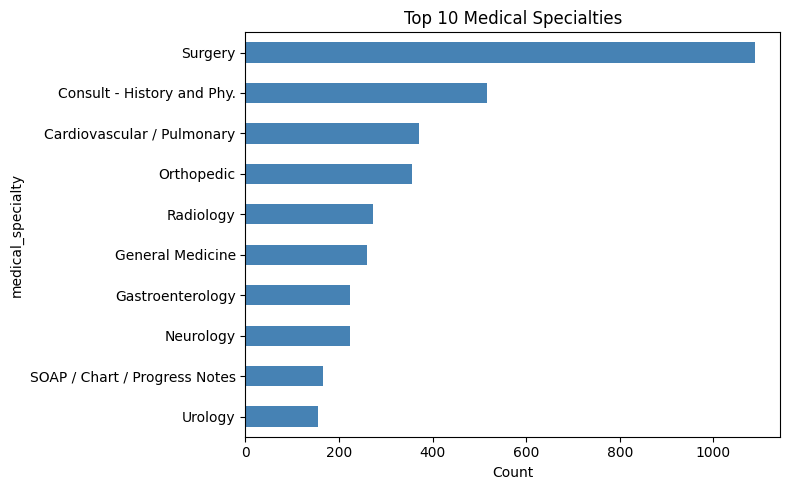

In [5]:
import matplotlib.pyplot as plt

df['medical_specialty'].value_counts().plot(kind='barh', figsize=(8,5), color='steelblue')
plt.xlabel('Count')
plt.title('Top 10 Medical Specialties')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['label'] = le.fit_transform(df['medical_specialty'])

X_train, X_test, y_train, y_test = train_test_split(
    df['transcription'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)
print(X_train.shape, X_test.shape)

(2904,) (727,)


In [7]:
# dedupe, optional drop of document-type classes, then train/val/test split

before = len(df)
df = df.drop_duplicates(subset='transcription').reset_index(drop=True)
print(f"dropped {before - len(df)} duplicate transcriptions")

# toggle: set True for the second run without non-specialty classes
DROP_DOC_TYPES = False
doc_types = ['Consult - History and Phy.', 'SOAP / Chart / Progress Notes',
             'Discharge Summary', 'Emergency Room Reports']
if DROP_DOC_TYPES:
    df = df[~df['medical_specialty'].isin(doc_types)].reset_index(drop=True)

# re-encode labels (class set may have changed)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
df['label'] = le.fit_transform(df['medical_specialty'])

# only the transcription is used as input (no keywords, sample_name, description)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    df['transcription'], df['label'], test_size=0.1,
    random_state=42, stratify=df['label'])

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.111,  # ~10% of the full data
    random_state=42, stratify=y_trainval)

print(len(X_train), len(X_val), len(X_test))
print(df['medical_specialty'].value_counts())

dropped 1440 duplicate transcriptions
1752 219 220
medical_specialty
Surgery                          982
Radiology                        248
General Medicine                 204
Consult - History and Phy.       201
Urology                          156
SOAP / Chart / Progress Notes    145
Neurology                         94
Orthopedic                        65
Cardiovascular / Pulmonary        55
Gastroenterology                  41
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import StratifiedKFold

X_all = df['transcription'].reset_index(drop=True)
y_all = df['label'].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = []
for tr_idx, te_idx in skf.split(X_all, y_all):
    # carve 10% of train as val for model selection
    tr_idx, va_idx = train_test_split(
        tr_idx, test_size=0.1, random_state=42, stratify=y_all[tr_idx])
    folds.append((tr_idx, va_idx, te_idx))

print([ (len(a), len(b), len(c)) for a,b,c in folds ])

[(1576, 176, 439), (1577, 176, 438), (1577, 176, 438), (1577, 176, 438), (1577, 176, 438)]


In [10]:
!pip install -q transformers accelerate tqdm ipywidgets

import gc, torch, numpy as np
from tqdm.notebook import tqdm
from torch.utils.data import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, EarlyStoppingCallback)
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

# ---------- model ----------
MODEL = "emilyalsentzer/Bio_ClinicalBERT"
tok = AutoTokenizer.from_pretrained(MODEL)

# ---------- data ----------
def encode(text, max_len=512):
    ids = tok(text, add_special_tokens=False, truncation=False)["input_ids"]
    keep = max_len - 2
    if len(ids) > keep:  # head + tail truncation
        ids = ids[:keep // 2] + ids[-(keep - keep // 2):]
    ids = [tok.cls_token_id] + ids + [tok.sep_token_id]
    pad = max_len - len(ids)
    return ids + [tok.pad_token_id] * pad, [1] * len(ids) + [0] * pad

class DS(Dataset):
    def __init__(self, X, y, desc="Tokenizing"):
        self.enc = [encode(t) for t in tqdm(X, desc=desc)]
        self.y = list(y)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        ids, mask = self.enc[i]
        return {"input_ids": torch.tensor(ids),
                "attention_mask": torch.tensor(mask),
                "labels": torch.tensor(int(self.y[i]))}

# ---------- single fold ----------
X_all = df['transcription'].reset_index(drop=True)
y_all = df['label'].reset_index(drop=True)
tr, va, te = folds[0]

train_ds = DS(X_all[tr], y_all[tr], "Tokenizing train")
val_ds   = DS(X_all[va], y_all[va], "Tokenizing val")
test_ds  = DS(X_all[te], y_all[te], "Tokenizing test")

n_classes = len(le.classes_)
cw = compute_class_weight("balanced", classes=np.arange(n_classes), y=y_all[tr])
cw = torch.tensor(cw, dtype=torch.float).cuda()

class WTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        loss = torch.nn.CrossEntropyLoss(weight=cw)(out.logits, labels)
        return (loss, out) if return_outputs else loss

def metrics(p):
    preds = p.predictions.argmax(-1)
    return {"acc": accuracy_score(p.label_ids, preds),
            "macro_f1": f1_score(p.label_ids, preds, average="macro")}

model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=n_classes)

args = TrainingArguments(
    output_dir="out/fold0", num_train_epochs=5, learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    weight_decay=0.01, warmup_steps=50, fp16=True, seed=42,
    report_to="none", disable_tqdm=False, logging_strategy="epoch")

trainer = WTrainer(model=model, args=args, train_dataset=train_ds,
                   eval_dataset=val_ds, compute_metrics=metrics,
                   callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer.train()

# ---------- final test ----------
out = trainer.predict(test_ds)
pred = out.predictions.argmax(-1)
true = y_all[te].values
print(f"acc={accuracy_score(true, pred):.4f}  macro_f1={f1_score(true, pred, average='macro'):.4f}")
print(classification_report(true, pred, target_names=le.classes_, digits=3))

Tokenizing train:   0%|          | 0/1576 [00:00<?, ?it/s]

Tokenizing val:   0%|          | 0/176 [00:00<?, ?it/s]

Tokenizing test:   0%|          | 0/439 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.7813  macro_f1=0.6558
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary      0.667     0.909     0.769        11
   Consult - History and Phy.      0.545     0.293     0.381        41
             Gastroenterology      0.278     0.625     0.385         8
             General Medicine      0.556     0.610     0.581        41
                    Neurology      0.462     0.632     0.533        19
                   Orthopedic      0.588     0.769     0.667        13
                    Radiology      0.850     0.694     0.764        49
SOAP / Chart / Progress Notes      0.688     0.759     0.721        29
                      Surgery      0.989     0.949     0.969       197
                      Urology      0.743     0.839     0.788        31

                     accuracy                          0.781       439
                    macro avg      0.637     0.708     0.656       439
                 weighted avg      0.799     0.

In [11]:
args2 = TrainingArguments(
    output_dir="out/fold0_cont", num_train_epochs=5, learning_rate=1e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    weight_decay=0.01, warmup_steps=0, fp16=True, seed=43,
    report_to="none", disable_tqdm=False, logging_strategy="epoch")

trainer2 = WTrainer(model=trainer.model, args=args2, train_dataset=train_ds,
                    eval_dataset=val_ds, compute_metrics=metrics,
                    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer2.train()

out = trainer2.predict(test_ds)
pred = out.predictions.argmax(-1)
true = y_all[te].values
print(f"acc={accuracy_score(true, pred):.4f}  macro_f1={f1_score(true, pred, average='macro'):.4f}")
print(classification_report(true, pred, target_names=le.classes_, digits=3))

Epoch,Training Loss,Validation Loss,Acc,Macro F1
1,0.695828,1.031031,0.806818,0.664228
2,0.535507,1.039871,0.812500,0.637988
3,0.406886,0.990978,0.801136,0.650219


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.7927  macro_f1=0.6876
                               precision    recall  f1-score   support

   Cardiovascular / Pulmonary      0.625     0.909     0.741        11
   Consult - History and Phy.      0.500     0.317     0.388        41
             Gastroenterology      0.625     0.625     0.625         8
             General Medicine      0.521     0.610     0.562        41
                    Neurology      0.500     0.579     0.537        19
                   Orthopedic      0.733     0.846     0.786        13
                    Radiology      0.854     0.714     0.778        49
SOAP / Chart / Progress Notes      0.605     0.793     0.687        29
                      Surgery      0.990     0.959     0.974       197
                      Urology      0.765     0.839     0.800        31

                     accuracy                          0.793       439
                    macro avg      0.672     0.719     0.688       439
                 weighted avg      0.799     0.

In [12]:
import gc, torch, numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoModelForSequenceClassification, TrainingArguments,
                          EarlyStoppingCallback)

# free the previous run
for v in ["model", "trainer", "trainer2"]:
    if v in globals():
        del globals()[v]
gc.collect(); torch.cuda.empty_cache()

# ---------- data without document-type classes ----------
doc_types = ['Consult - History and Phy.', 'SOAP / Chart / Progress Notes',
             'Discharge Summary', 'Emergency Room Reports']
df2 = df[~df['medical_specialty'].isin(doc_types)].reset_index(drop=True)

le2 = LabelEncoder()
df2['label'] = le2.fit_transform(df2['medical_specialty'])
print(df2['medical_specialty'].value_counts())

X2 = df2['transcription'].reset_index(drop=True)
y2 = df2['label'].reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds2 = []
for tr_i, te_i in skf.split(X2, y2):
    tr_i, va_i = train_test_split(tr_i, test_size=0.1, random_state=42,
                                  stratify=y2[tr_i])
    folds2.append((tr_i, va_i, te_i))

tr, va, te = folds2[0]
print(len(tr), len(va), len(te))

train_ds2 = DS(X2[tr], y2[tr], "Tokenizing train")
val_ds2   = DS(X2[va], y2[va], "Tokenizing val")
test_ds2  = DS(X2[te], y2[te], "Tokenizing test")

# ---------- class weights (WTrainer reads the global `cw`) ----------
n_classes = len(le2.classes_)
cw = compute_class_weight("balanced", classes=np.arange(n_classes), y=y2[tr])
cw = torch.tensor(cw, dtype=torch.float).cuda()

# ---------- fresh model ----------
model2 = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=n_classes)

args = TrainingArguments(
    output_dir="out/nodoc_fold0", num_train_epochs=6, learning_rate=2e-5,
    per_device_train_batch_size=16, per_device_eval_batch_size=32,
    eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="macro_f1",
    weight_decay=0.01, warmup_steps=50, fp16=True, seed=42,
    report_to="none", disable_tqdm=False, logging_strategy="epoch")

trainer3 = WTrainer(model=model2, args=args, train_dataset=train_ds2,
                    eval_dataset=val_ds2, compute_metrics=metrics,
                    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
trainer3.train()

# ---------- final test ----------
out = trainer3.predict(test_ds2)
pred = out.predictions.argmax(-1)
true = y2[te].values
print(f"acc={accuracy_score(true, pred):.4f}  macro_f1={f1_score(true, pred, average='macro'):.4f}")
print(classification_report(true, pred, target_names=le2.classes_, digits=3))

medical_specialty
Surgery                       982
Radiology                     248
General Medicine              204
Urology                       156
Neurology                      94
Orthopedic                     65
Cardiovascular / Pulmonary     55
Gastroenterology               41
Name: count, dtype: int64
1328 148 369


Tokenizing train:   0%|          | 0/1328 [00:00<?, ?it/s]

Tokenizing val:   0%|          | 0/148 [00:00<?, ?it/s]

Tokenizing test:   0%|          | 0/369 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.8699  macro_f1=0.7719
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary      0.818     0.818     0.818        11
          Gastroenterology      0.545     0.750     0.632         8
          General Medicine      0.833     0.732     0.779        41
                 Neurology      0.524     0.579     0.550        19
                Orthopedic      0.684     1.000     0.812        13
                 Radiology      0.804     0.755     0.779        49
                   Surgery      0.989     0.949     0.969       197
                   Urology      0.778     0.903     0.836        31

                  accuracy                          0.870       369
                 macro avg      0.747     0.811     0.772       369
              weighted avg      0.880     0.870     0.873       369



In [13]:
MODEL = "allenai/longformer-base-4096"
tok = AutoTokenizer.from_pretrained(MODEL)
encode.__defaults__ = (1024,)

tr_ds = DS(X2[tr], y2[tr], "train")
va_ds = DS(X2[va], y2[va], "val")
te_ds = DS(X2[te], y2[te], "test")

m = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=n_classes)
a = TrainingArguments(
    output_dir="out/longformer", num_train_epochs=6, learning_rate=3e-5,
    per_device_train_batch_size=4, gradient_accumulation_steps=4,
    per_device_eval_batch_size=8, eval_strategy="epoch", save_strategy="epoch",
    save_total_limit=1, load_best_model_at_end=True,
    metric_for_best_model="macro_f1", warmup_steps=30, fp16=True,
    seed=42, report_to="none")
t4 = WTrainer(model=m, args=a, train_dataset=tr_ds, eval_dataset=va_ds,
              compute_metrics=metrics,
              callbacks=[EarlyStoppingCallback(early_stopping_patience=2)])
t4.train()

p = t4.predict(te_ds).predictions.argmax(-1)
print(f"acc={accuracy_score(true, p):.4f} macro_f1={f1_score(true, p, average='macro'):.4f}")
print(classification_report(true, p, target_names=le2.classes_, digits=3))

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

train:   0%|          | 0/1328 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

acc=0.8726 macro_f1=0.7261
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary      0.750     0.545     0.632        11
          Gastroenterology      0.600     0.375     0.462         8
          General Medicine      0.766     0.878     0.818        41
                 Neurology      0.667     0.421     0.516        19
                Orthopedic      0.688     0.846     0.759        13
                 Radiology      0.759     0.898     0.822        49
                   Surgery      0.974     0.959     0.967       197
                   Urology      0.862     0.806     0.833        31

                  accuracy                          0.873       369
                 macro avg      0.758     0.716     0.726       369
              weighted avg      0.872     0.873     0.868       369



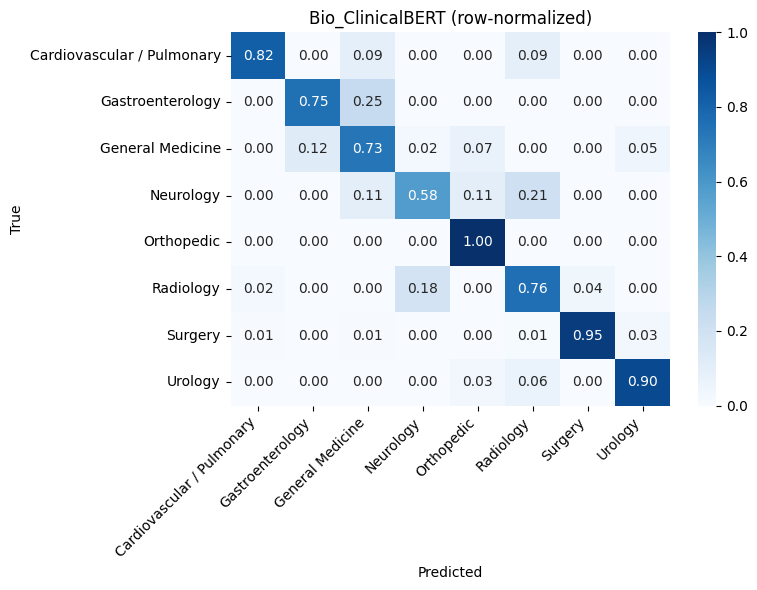

In [14]:
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true, pred, normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le2.classes_, yticklabels=le2.classes_)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Bio_ClinicalBERT (row-normalized)')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig('cm_clinicalbert.png', dpi=300); plt.show()

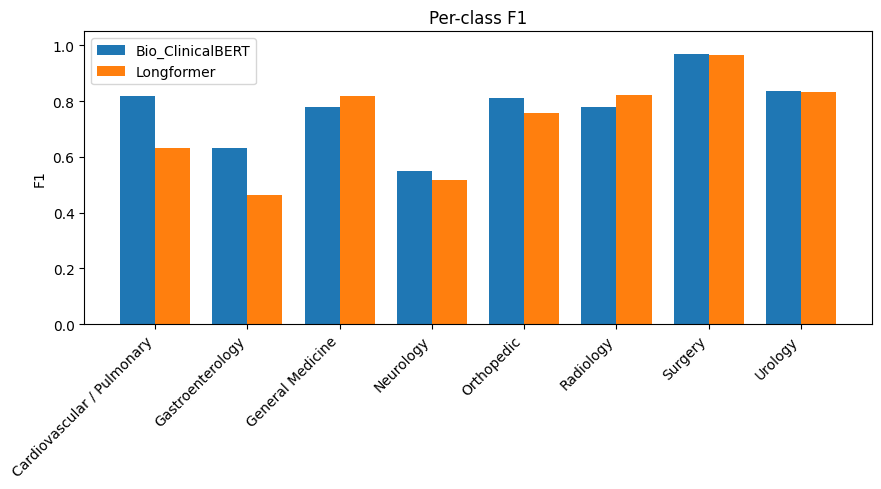

In [15]:
import numpy as np
from sklearn.metrics import f1_score

f_c = f1_score(true, pred, average=None)
f_l = f1_score(true, p, average=None)
x = np.arange(len(le2.classes_)); w = 0.38

plt.figure(figsize=(9,5))
plt.bar(x - w/2, f_c, w, label='Bio_ClinicalBERT')
plt.bar(x + w/2, f_l, w, label='Longformer')
plt.xticks(x, le2.classes_, rotation=45, ha='right')
plt.ylabel('F1'); plt.ylim(0,1.05); plt.legend()
plt.title('Per-class F1'); plt.tight_layout()
plt.savefig('f1_per_class.png', dpi=300); plt.show()

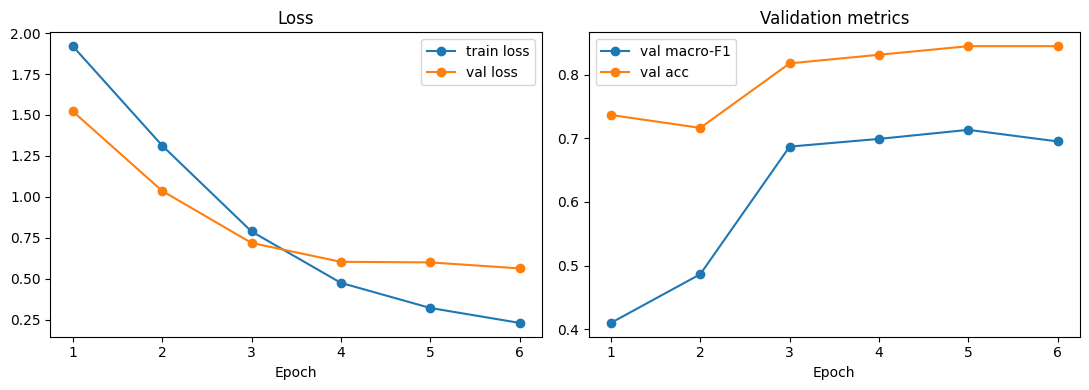

In [16]:
log = trainer3.state.log_history
tr_l = [(l['epoch'], l['loss']) for l in log if 'loss' in l]
ev = [l for l in log if 'eval_loss' in l]

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(*zip(*tr_l), marker='o', label='train loss')
ax[0].plot([e['epoch'] for e in ev], [e['eval_loss'] for e in ev], marker='o', label='val loss')
ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].set_title('Loss')
ax[1].plot([e['epoch'] for e in ev], [e['eval_macro_f1'] for e in ev], marker='o', label='val macro-F1')
ax[1].plot([e['epoch'] for e in ev], [e['eval_acc'] for e in ev], marker='o', label='val acc')
ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].set_title('Validation metrics')
plt.tight_layout(); plt.savefig('curves.png', dpi=300); plt.show()